In [1]:
import pyspark
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np

In [3]:
spark=SparkSession.builder \
     .appName("Pyspark Basics") \
    .getOrCreate()

In [4]:
data=spark.read.csv("/content/stocks.txt",header=True,inferSchema=True)

In [5]:
data.show()

+---+----------------+-----------+--------+-------+
| id|            name|   category|quantity|  price|
+---+----------------+-----------+--------+-------+
|  1|          iPhone|Electronics|      10| 899.99|
|  2|         Macbook|Electronics|       5|1299.99|
|  3|            iPad|Electronics|      15| 499.99|
|  4|      Samsung TV|Electronics|       8| 799.99|
|  5|           LG TV|Electronics|      10| 699.99|
|  6|      Nike Shoes|   Clothing|      30|  99.99|
|  7|    Adidas Shoes|   Clothing|      25|  89.99|
|  8| Sony Headphones|Electronics|      12| 149.99|
|  9|Beats Headphones|Electronics|      20| 199.99|
| 10|    Dining Table|  Furniture|      10| 249.99|
| 11|      Study Desk|  Furniture|       8| 149.99|
| 12|          Apples|       Food|     100|    0.5|
| 13|         Bananas|       Food|     150|   0.25|
| 14|         Oranges|       Food|     120|   0.75|
| 15|  Chicken Breast|       Food|      50|   3.99|
| 16|   Salmon Fillet|       Food|      30|   5.99|
| 17|  Leath

In [6]:
data.printSchema()

root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- price: double (nullable = true)



In [7]:
data.count()

30

In [8]:
data.describe() .show()

+-------+-----------------+------------+-----------+-----------------+------------------+
|summary|               id|        name|   category|         quantity|             price|
+-------+-----------------+------------+-----------+-----------------+------------------+
|  count|               30|          30|         30|               30|                30|
|   mean|             15.5|        NULL|       NULL|             29.3|227.37433333333317|
| stddev|8.803408430829505|        NULL|       NULL|34.80006936180166|320.66170023533545|
|    min|                1|Adidas Shoes|Accessories|                5|              0.25|
|    max|               30|      iPhone|     Sports|              150|           1299.99|
+-------+-----------------+------------+-----------+-----------------+------------------+



In [9]:
selected_data = data.select("id", "price")

In [10]:
selected_data.show()

+---+-------+
| id|  price|
+---+-------+
|  1| 899.99|
|  2|1299.99|
|  3| 499.99|
|  4| 799.99|
|  5| 699.99|
|  6|  99.99|
|  7|  89.99|
|  8| 149.99|
|  9| 199.99|
| 10| 249.99|
| 11| 149.99|
| 12|    0.5|
| 13|   0.25|
| 14|   0.75|
| 15|   3.99|
| 16|   5.99|
| 17| 199.99|
| 18| 149.99|
| 19|  19.99|
| 20|  49.99|
+---+-------+
only showing top 20 rows


In [16]:
data.filter(data.category == "Electronics").show()

+---+----------------+-----------+--------+-------+
| id|            name|   category|quantity|  price|
+---+----------------+-----------+--------+-------+
|  1|          iPhone|Electronics|      10| 899.99|
|  2|         Macbook|Electronics|       5|1299.99|
|  3|            iPad|Electronics|      15| 499.99|
|  4|      Samsung TV|Electronics|       8| 799.99|
|  5|           LG TV|Electronics|      10| 699.99|
|  8| Sony Headphones|Electronics|      12| 149.99|
|  9|Beats Headphones|Electronics|      20| 199.99|
| 26|          Camera|Electronics|      10| 599.99|
| 27|         Printer|Electronics|       8| 129.99|
+---+----------------+-----------+--------+-------+



In [19]:
data.filter(data.price > 500).show()

+---+----------+-----------+--------+-------+
| id|      name|   category|quantity|  price|
+---+----------+-----------+--------+-------+
|  1|    iPhone|Electronics|      10| 899.99|
|  2|   Macbook|Electronics|       5|1299.99|
|  4|Samsung TV|Electronics|       8| 799.99|
|  5|     LG TV|Electronics|      10| 699.99|
| 26|    Camera|Electronics|      10| 599.99|
+---+----------+-----------+--------+-------+



In [25]:
data_with_new_column = data.withColumn("Avg_price", data["price"] / data["quantity"])

In [26]:
data_with_new_column.show()

+---+----------------+-----------+--------+-------+--------------------+
| id|            name|   category|quantity|  price|           Avg_price|
+---+----------------+-----------+--------+-------+--------------------+
|  1|          iPhone|Electronics|      10| 899.99|              89.999|
|  2|         Macbook|Electronics|       5|1299.99|             259.998|
|  3|            iPad|Electronics|      15| 499.99|   33.33266666666667|
|  4|      Samsung TV|Electronics|       8| 799.99|            99.99875|
|  5|           LG TV|Electronics|      10| 699.99|              69.999|
|  6|      Nike Shoes|   Clothing|      30|  99.99|  3.3329999999999997|
|  7|    Adidas Shoes|   Clothing|      25|  89.99|  3.5995999999999997|
|  8| Sony Headphones|Electronics|      12| 149.99|  12.499166666666667|
|  9|Beats Headphones|Electronics|      20| 199.99|   9.999500000000001|
| 10|    Dining Table|  Furniture|      10| 249.99|  24.999000000000002|
| 11|      Study Desk|  Furniture|       8| 149.99|

In [27]:
data_with_new_column.describe().show()

+-------+-----------------+------------+-----------+-----------------+------------------+--------------------+
|summary|               id|        name|   category|         quantity|             price|           Avg_price|
+-------+-----------------+------------+-----------+-----------------+------------------+--------------------+
|  count|               30|          30|         30|               30|                30|                  30|
|   mean|             15.5|        NULL|       NULL|             29.3|227.37433333333317|  26.267932222222225|
| stddev|8.803408430829505|        NULL|       NULL|34.80006936180166|320.66170023533545|   51.67235468186936|
|    min|                1|Adidas Shoes|Accessories|                5|              0.25|0.001666666666666...|
|    max|               30|      iPhone|     Sports|              150|           1299.99|             259.998|
+-------+-----------------+------------+-----------+-----------------+------------------+--------------------+



In [29]:
grouped_data = data.groupBy("category").agg({"quantity": "sum"})
grouped_data.show()

+-----------+-------------+
|   category|sum(quantity)|
+-----------+-------------+
|       Food|          450|
|     Sports|           35|
|Electronics|           98|
|   Clothing|          200|
|  Furniture|           41|
|Accessories|           55|
+-----------+-------------+



In [30]:
average_value = data.selectExpr("avg(price)").collect()[0][0]
print(average_value)

227.37433333333317


In [31]:
average_value

227.37433333333317

In [32]:
grouped_data.show()

+-----------+-------------+
|   category|sum(quantity)|
+-----------+-------------+
|       Food|          450|
|     Sports|           35|
|Electronics|           98|
|   Clothing|          200|
|  Furniture|           41|
|Accessories|           55|
+-----------+-------------+



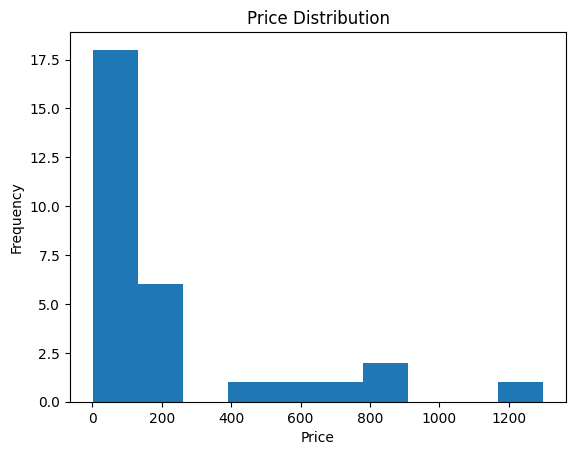

In [33]:
import matplotlib.pyplot as plt

pandas_data = data.toPandas()

plt.hist(pandas_data["price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

In [34]:
data.write.csv("output", header=True, mode="overwrite")

In [35]:
data.write.parquet("output.parquet")